# PDE time series to generators with confidence

This is the v0.17 quickstart. The story is deliberately linear:

`PDE time series -> FieldBatch -> residual target -> fitted generator -> verification -> confidence card`

The confidence card is a teaching pattern, not a package API. It collects the numerical evidence you should inspect before trusting a discovered generator.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np

from notebooks._tutorial_utils import (
    confidence_card,
    plot_field_heatmap,
    plot_singular_values,
    plot_verification_curve,
    print_cards,
)
from pdelie.data import generate_heat_1d_field_batch, generate_kdv_1d_field_batch, split_batch_train_heldout
from pdelie.derivatives import compute_spectral_fd_derivatives
from pdelie.reporting import (
    summarize_generator_fit_diagnostics,
    summarize_residual_batch,
    summarize_verification_report,
)
from pdelie.residuals import HeatResidualEvaluator, KdVResidualEvaluator
from pdelie.symmetry import fit_translation_generator
from pdelie.verification import verify_translation_generator

CONFIG = {
    "fit_epsilon": 1e-4,
    "verification_epsilons": None,
    "span_tolerance": 5e-2,
    "heat_seed_train": 100,
    "heat_seed_heldout": 101,
    "kdv_seed": 9001,
}
CONFIG


{'fit_epsilon': 0.0001,
 'verification_epsilons': None,
 'span_tolerance': 0.05,
 'heat_seed_train': 100,
 'heat_seed_heldout': 101,
 'kdv_seed': 9001}

## 1. Canonical fields are the common currency

`FieldBatch` is the object that lets data generation, residual evaluation, fitting, verification, and downstream helpers agree on axes, coordinates, variables, metadata, and provenance.


dims: ('batch', 'time', 'x', 'var')
shape: (4, 33, 64, 1)
metadata parameter tags: {'nu': 0.1}


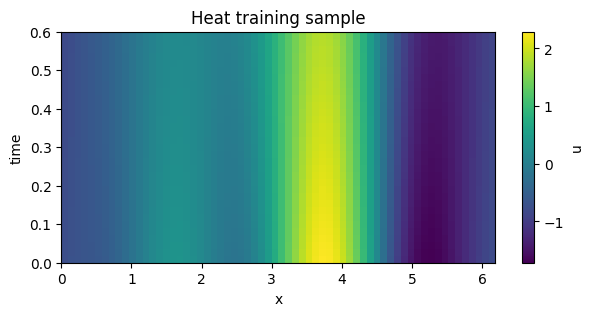

In [2]:
heat_train = generate_heat_1d_field_batch(batch_size=4, num_times=33, num_points=64, seed=CONFIG["heat_seed_train"])
heat_heldout = generate_heat_1d_field_batch(batch_size=3, num_times=33, num_points=64, seed=CONFIG["heat_seed_heldout"])

print("dims:", heat_train.dims)
print("shape:", heat_train.values.shape)
print("metadata parameter tags:", heat_train.metadata["parameter_tags"])
plot_field_heatmap(heat_train, title="Heat training sample")


## 2. Residuals define the scientific target

PDELie does not fit symmetries in a vacuum. A generator is meaningful only relative to the residual it preserves.


In [3]:
heat_derivatives = compute_spectral_fd_derivatives(heat_train)
heat_evaluator = HeatResidualEvaluator()
heat_residual = heat_evaluator.evaluate(heat_train, heat_derivatives)
heat_residual_summary = summarize_residual_batch(heat_residual)
heat_residual_summary


{'summary_schema_version': '0.1',
 'summary_type': 'residual_batch',
 'residual_shape': [4, 33, 64, 1],
 'definition_type': 'analytic',
 'normalization': 'none',
 'max_abs_residual': 5.0258378954559646e-05,
 'rms_residual': 1.0771339104663567e-05,
 'diagnostics': {'backend': 'spectral_fd',
  'nu': 0.1,
  'max_abs_residual': 5.0258378954559646e-05}}

## 3. Fit, verify, then inspect the confidence card

The fitted object is a `GeneratorFamily`. The confidence card summarizes residual health, fit conditioning, span evidence, and held-out finite-transform verification.


[
  {
    "condition_number": 835444.9972869015,
    "evidence_label": "direct_svd_in_tolerance",
    "first_epsilon": 0.0001,
    "first_error": 2.67270190813303e-09,
    "fit_mode": "svd",
    "label": "heat fitted translation",
    "max_error": 2.6627098369001555e-06,
    "reference_fallback_used": false,
    "residual_max_abs": 5.0258378954559646e-05,
    "residual_rms": 1.0771339104663567e-05,
    "selected_span_distance": 9.269826737488421e-06,
    "singular_value_count": 4,
    "svd_span_distance": 9.269826737488421e-06,
    "verification_classification": "exact"
  }
]


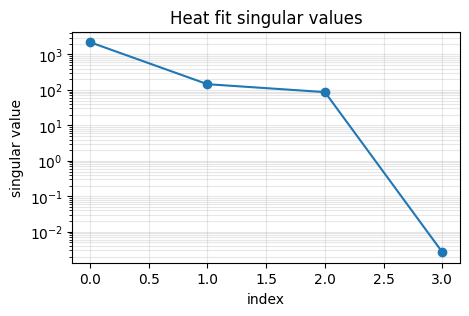

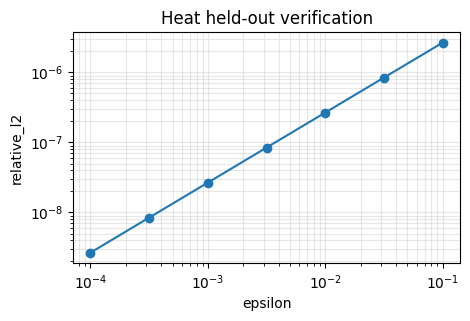

In [4]:
heat_generator = fit_translation_generator(
    heat_train,
    heat_evaluator,
    epsilon=CONFIG["fit_epsilon"],
)
heat_verification = verify_translation_generator(
    heat_heldout,
    heat_generator,
    heat_evaluator,
    epsilon_values=CONFIG["verification_epsilons"],
    span_tolerance=CONFIG["span_tolerance"],
)

heat_fit_summary = summarize_generator_fit_diagnostics(heat_generator)
heat_verification_summary = summarize_verification_report(heat_verification)
heat_card = confidence_card(
    label="heat fitted translation",
    residual=heat_residual_summary,
    fit=heat_fit_summary,
    verification=heat_verification_summary,
)
print_cards([heat_card])
plot_singular_values(heat_fit_summary, title="Heat fit singular values")
plot_verification_curve(heat_verification_summary, title="Heat held-out verification")


## 4. Same workflow, harder PDE

KdV uses the same object pipeline but requires third spatial derivatives. This cell is intentionally a comparison, not a general KdV stability claim.


[
  {
    "condition_number": 835444.9972869015,
    "evidence_label": "direct_svd_in_tolerance",
    "first_epsilon": 0.0001,
    "first_error": 2.67270190813303e-09,
    "fit_mode": "svd",
    "label": "heat fitted translation",
    "max_error": 2.6627098369001555e-06,
    "reference_fallback_used": false,
    "residual_max_abs": 5.0258378954559646e-05,
    "residual_rms": 1.0771339104663567e-05,
    "selected_span_distance": 9.269826737488421e-06,
    "singular_value_count": 4,
    "svd_span_distance": 9.269826737488421e-06,
    "verification_classification": "exact"
  },
  {
    "condition_number": 37832.989505871956,
    "evidence_label": "direct_svd_in_tolerance",
    "first_epsilon": 0.0001,
    "first_error": 3.7632323492784305e-06,
    "fit_mode": "svd",
    "label": "KdV fitted translation",
    "max_error": 0.0037167390221531527,
    "reference_fallback_used": false,
    "residual_max_abs": 0.0029755398453998883,
    "residual_rms": 0.0005530662104030956,
    "selected_span_

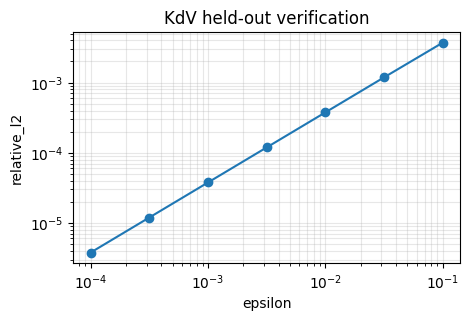

In [5]:
kdv_field = generate_kdv_1d_field_batch(batch_size=5, seed=CONFIG["kdv_seed"])
kdv_train, kdv_heldout = split_batch_train_heldout(kdv_field, train_size=2, seed=9002)
kdv_evaluator = KdVResidualEvaluator()
kdv_derivatives = compute_spectral_fd_derivatives(kdv_train, max_spatial_order=3)
kdv_residual = kdv_evaluator.evaluate(kdv_train, kdv_derivatives)
kdv_generator = fit_translation_generator(kdv_train, kdv_evaluator, epsilon=CONFIG["fit_epsilon"])
kdv_verification = verify_translation_generator(kdv_heldout, kdv_generator, kdv_evaluator)

kdv_residual_summary = summarize_residual_batch(kdv_residual)
kdv_fit_summary = summarize_generator_fit_diagnostics(kdv_generator)
kdv_verification_summary = summarize_verification_report(kdv_verification)
kdv_card = confidence_card(
    label="KdV fitted translation",
    residual=kdv_residual_summary,
    fit=kdv_fit_summary,
    verification=kdv_verification_summary,
)
print_cards([heat_card, kdv_card])
plot_verification_curve(kdv_verification_summary, title="KdV held-out verification")


## Takeaway

A generator is not just coefficients. For tutorial and research use, report the residual, fit diagnostics, span evidence, and held-out verification together. That is the practical meaning of “generators out with confidence.”
